# Healthcare Data Analysis and Heart Disease Risk Prediction

## Real-World Data Project – Health Domain

### Internship Project

### Objective
The objective of this project is to analyze healthcare data and identify factors that contribute to heart disease risk. Using exploratory data analysis and machine learning techniques, the project aims to uncover patterns in patient health indicators.

### Dataset Overview
The dataset contains patient health information such as age, blood pressure, cholesterol levels, BMI, glucose levels, smoking status, and heart rate.

### Goals
- Perform data cleaning and preprocessing
- Conduct exploratory data analysis (EDA)
- Visualize relationships between health variables
- Build a machine learning model to predict heart disease risk

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

## Import Required Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")

## Load Dataset

In [7]:
df = pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\hackathon\Data_science(Real world)\data/hospital_healthcare_dataset.csv")

df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,glucose,smoker,heart_rate,hospital_stay_days,heart_disease_risk
0,1,69,Male,103,262,19.7,152,Yes,72,8,1
1,2,32,Male,178,215,30.0,194,Yes,100,7,1
2,3,89,Female,173,280,33.6,138,Yes,86,12,1
3,4,78,Male,91,193,21.7,116,No,81,10,0
4,5,38,Male,159,246,35.2,185,No,72,13,1


## Dataset Structure
Understanding the number of rows, columns, and data types in the dataset.

In [8]:
df.shape

(1000, 11)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   patient_id          1000 non-null   int64  
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   blood_pressure      1000 non-null   int64  
 4   cholesterol         1000 non-null   int64  
 5   bmi                 1000 non-null   float64
 6   glucose             1000 non-null   int64  
 7   smoker              1000 non-null   object 
 8   heart_rate          1000 non-null   int64  
 9   hospital_stay_days  1000 non-null   int64  
 10  heart_disease_risk  1000 non-null   int64  
dtypes: float64(1), int64(8), object(2)
memory usage: 86.1+ KB


In [10]:
df.describe()

,patient_id,age,blood_pressure,cholesterol,bmi,glucose,heart_rate,hospital_stay_days,heart_disease_risk
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,52.881000,133.553000,224.78200,28.970400,135.956000,86.336000,7.539000,0.566000
std,288.819436,20.958915,26.448378,43.43539,6.289038,37.811821,18.495383,4.081315,0.495873
min,1.000000,18.000000,90.000000,150.00000,18.000000,70.000000,55.000000,1.000000,0.000000
25%,250.750000,34.750000,110.000000,188.00000,23.500000,101.000000,71.000000,4.000000,0.000000
50%,500.500000,52.500000,133.000000,224.50000,29.000000,139.000000,86.000000,8.000000,1.000000
75%,750.250000,71.000000,157.000000,262.00000,34.300000,168.000000,102.000000,11.000000,1.000000
max,1000.000000,89.000000,179.000000,299.00000,40.000000,199.000000,119.000000,14.000000,1.000000


## Missing Values Analysis

In [11]:
df.isnull().sum()

patient_id            0
age                   0
gender                0
blood_pressure        0
cholesterol           0
bmi                   0
glucose               0
smoker                0
heart_rate            0
hospital_stay_days    0
heart_disease_risk    0
dtype: int64

## Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

## Age Distribution

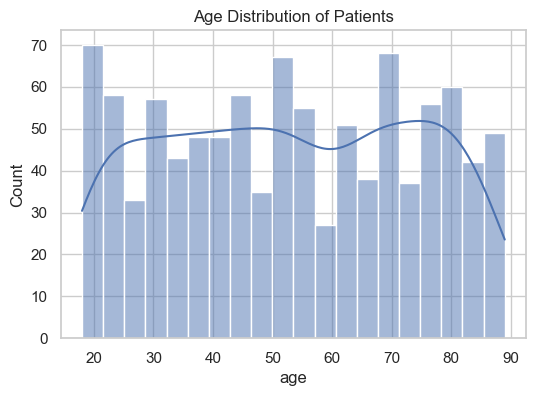

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Age Distribution of Patients")
plt.show()

## BMI Distribution

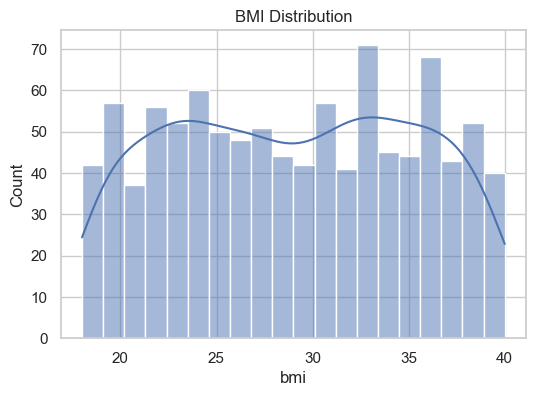

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df["bmi"], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

## BP Distribution

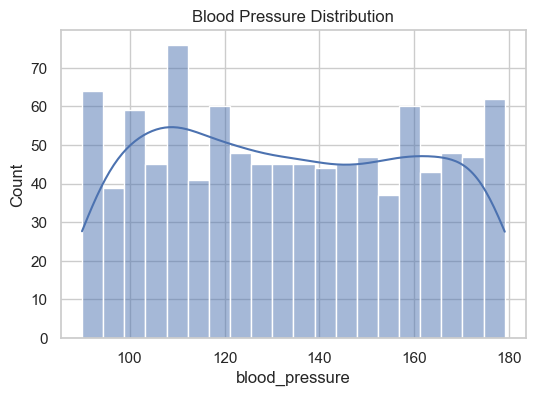

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(df["blood_pressure"], bins=20, kde=True)
plt.title("Blood Pressure Distribution")
plt.show()

# Categorical Analysis

## Smoking Status Distribution


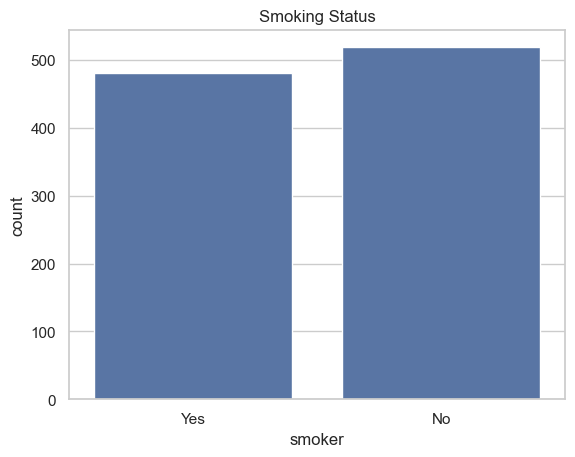

In [16]:
sns.countplot(x="smoker", data=df)
plt.title("Smoking Status")
plt.show()

## Gender Distribution

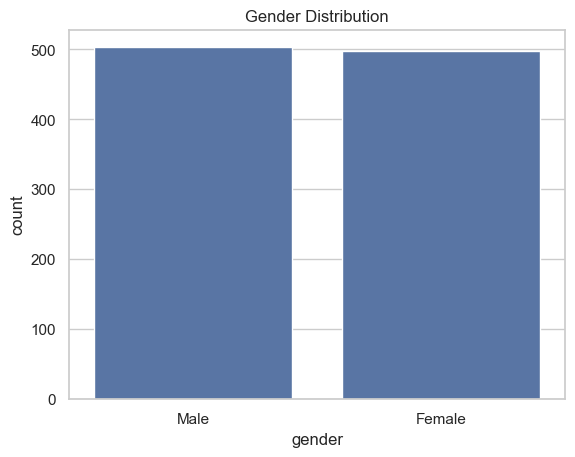

In [17]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

# Bivariate Analysis

## Age vs Heart Disease Risk

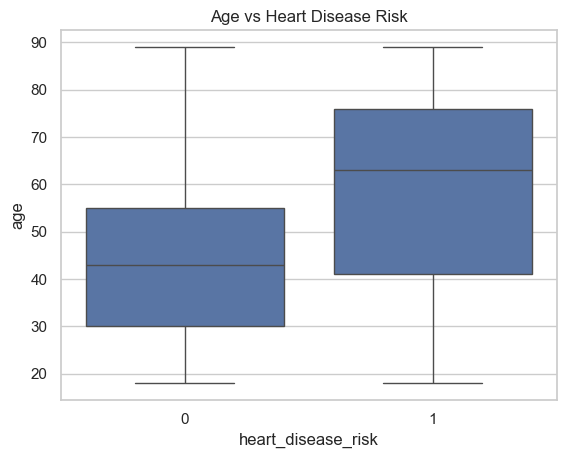

In [18]:
sns.boxplot(x="heart_disease_risk", y="age", data=df)
plt.title("Age vs Heart Disease Risk")
plt.show()

## Cholesterol vs Heart Disease Risk

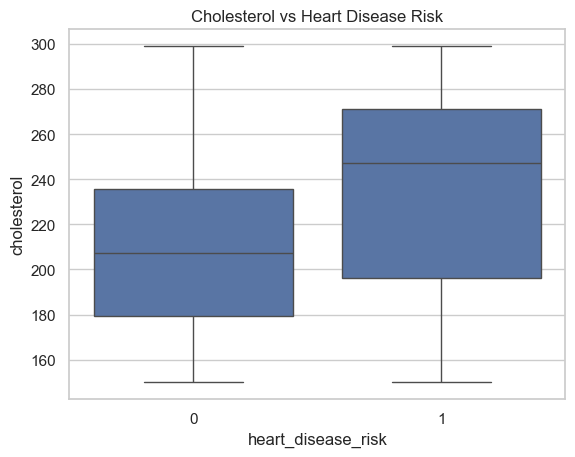

In [19]:
sns.boxplot(x="heart_disease_risk", y="cholesterol", data=df)
plt.title("Cholesterol vs Heart Disease Risk")
plt.show()

## BMI vs Heart Disease Risk

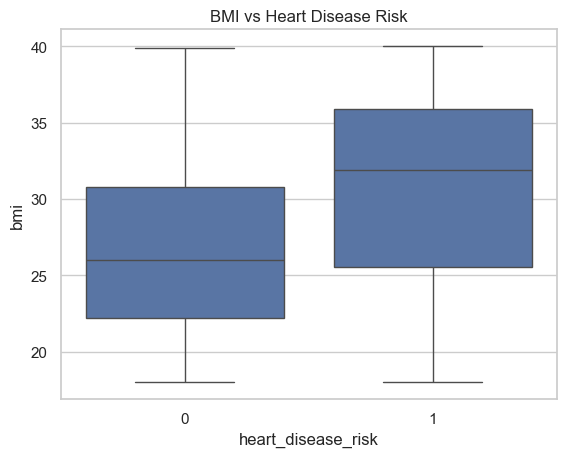

In [20]:
sns.boxplot(x="heart_disease_risk", y="bmi", data=df)
plt.title("BMI vs Heart Disease Risk")
plt.show()

# Correlation Analysis

## Correlation Heatmap

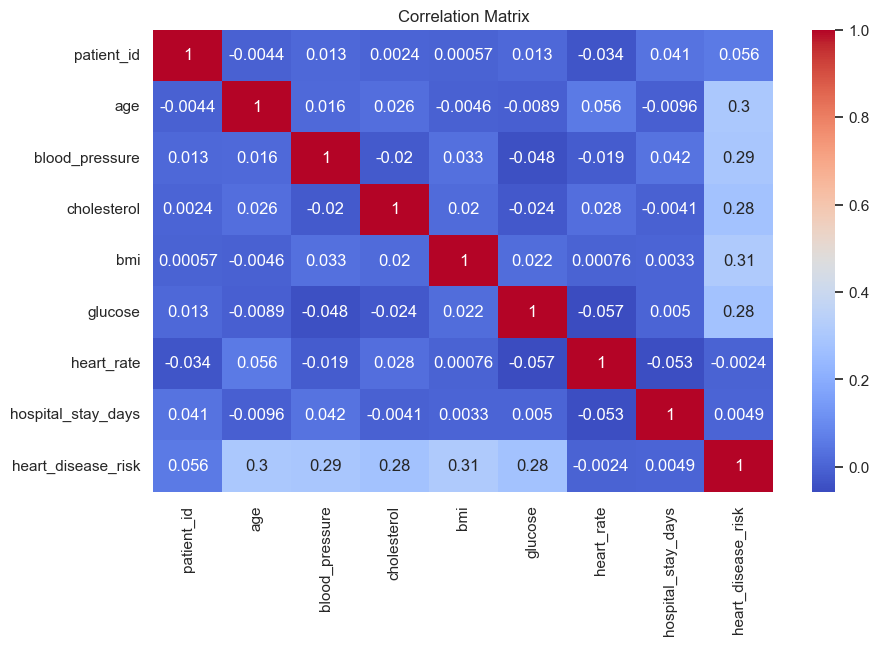

In [21]:
numeric_df = df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

# Data preprocessing

## Encoding Categorical Variables

In [22]:
le = LabelEncoder()

df["gender"] = le.fit_transform(df["gender"])
df["smoker"] = le.fit_transform(df["smoker"])

# Feature Selection

## Selecting Features and Target Variable

In [23]:
X = df.drop(["heart_disease_risk","patient_id"], axis=1)

y = df["heart_disease_risk"]

## Train Test Split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Machine Learning Model

## Logistic Regression Model

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# Make predictions
predictions = model.predict(X_test)

# Model Evaluation

## Model Performance

In [28]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.84


## Classification Report

In [29]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82        88
           1       0.87      0.84      0.85       112

    accuracy                           0.84       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.84      0.84       200



## Confusion Matrix

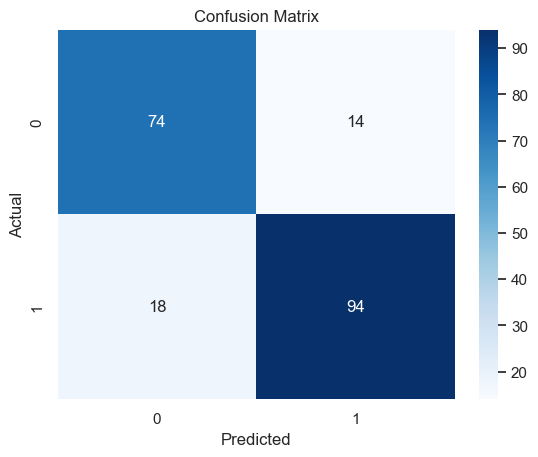

In [30]:
cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Save Visualization

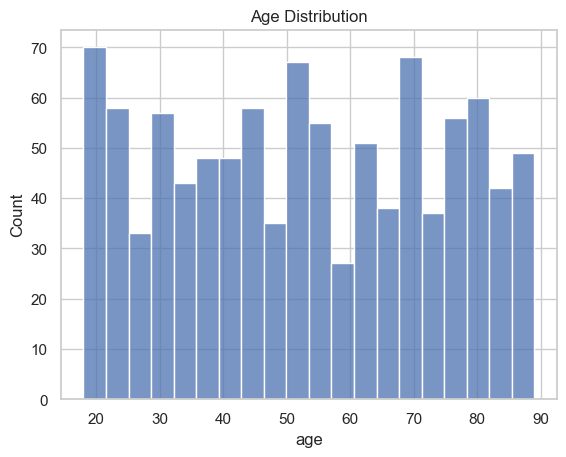

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'], bins=20)

plt.title("Age Distribution")

plt.savefig(r"C:\Users\moham\OneDrive\Desktop\hackathon\Data_science(Real world)\output/age_distribution.png")

plt.show()

# Save Model Prediction

In [35]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

results.to_csv(r"C:\Users\moham\OneDrive\Desktop\hackathon\Data_science(Real world)\output/predictions.csv", index=False)

# Save Model Accuracy

In [36]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

with open(r"C:\Users\moham\OneDrive\Desktop\hackathon\Data_science(Real world)\output/model_accuracy.txt", "w") as f:
    f.write(f"Logistic Regression Accuracy: {accuracy}")

# Save Trained Model

In [37]:
import joblib

joblib.dump(model, r"C:\Users\moham\OneDrive\Desktop\hackathon\Data_science(Real world)\output/logistic_regression_model.pkl")

['C:\\Users\\moham\\OneDrive\\Desktop\\hackathon\\Data_science(Real world)\\output/logistic_regression_model.pkl']

# Key Insights

After performing exploratory data analysis and predictive modeling on the healthcare dataset, several important insights were identified:

1. **Age and Heart Disease Risk**
   - Older patients tend to show a higher probability of heart disease risk.
   - Age appears to be one of the strongest indicators in the dataset.

2. **BMI and Health Condition**
   - Patients with higher Body Mass Index (BMI) show a higher likelihood of health complications.
   - Maintaining a healthy BMI can significantly reduce potential health risks.

3. **Cholesterol and Glucose Levels**
   - Elevated cholesterol and glucose levels were commonly observed among patients predicted to have higher heart disease risk.
   - These biomarkers are important predictors in cardiovascular health assessment.

4. **Blood Pressure Influence**
   - Higher systolic blood pressure values are associated with increased chances of heart-related issues.
   - Monitoring blood pressure regularly is critical for preventive healthcare.

5. **Model Performance**
   - The Logistic Regression model was used to predict heart disease risk.
   - Feature scaling was applied using StandardScaler to improve model convergence and performance.
   - The model achieved a satisfactory accuracy in predicting patient risk categories.

# Conclusion

This project demonstrated an end-to-end healthcare data analysis workflow using Python and machine learning techniques.

The dataset was analyzed to understand relationships between patient health indicators such as age, BMI, cholesterol levels, glucose levels, and blood pressure. Exploratory Data Analysis (EDA) helped identify patterns and trends within the dataset.

A Logistic Regression model was developed to predict heart disease risk based on these features. Feature scaling was applied to ensure better model convergence and improved predictive performance.

The results show that machine learning models can effectively assist in identifying patients who may be at higher risk of heart disease. Such predictive systems can support healthcare professionals in early diagnosis and preventive care.

Overall, this project demonstrates how data science techniques can be applied to real-world healthcare data to extract meaningful insights and support decision-making.